# C native plugins

propaq can load custom noise models and truncation policies from a plain C
shared library (see `examples/plugins/README.md` for the full ABI). This
notebook builds every C plugin in `examples/plugins/c/`, loads each one
through propaq's real `NativeNoiseModel`/`NativeTruncator` classes, and
checks for accuracy and concurrency.

## Building the plugins

Each `.c` file compiles to a standalone shared library with a plain `gcc` invocation.

In [ ]:
import subprocess
from pathlib import Path

PLUGIN_DIR = Path("../c").resolve()
BUILD_DIR = Path("_build").resolve()
BUILD_DIR.mkdir(exist_ok=True)

SOURCES = {
    "uniform_noise": PLUGIN_DIR / "noise/uniform_noise.c",
    "thermal_decay_noise": PLUGIN_DIR / "noise/thermal_decay_noise.c",
    "drifting_noise": PLUGIN_DIR / "noise/drifting_noise.c",
    "depth_dependent_noise": PLUGIN_DIR / "noise/depth_dependent_noise.c",
    "qubit_local_noise": PLUGIN_DIR / "noise/qubit_local_noise.c",
    "weight_truncator": PLUGIN_DIR / "truncation/weight_truncator.c",
    "pareto_truncator": PLUGIN_DIR / "truncation/pareto_truncator.c",
    "stochastic_truncator": PLUGIN_DIR / "truncation/stochastic_truncator.c",
    "support_truncator": PLUGIN_DIR / "truncation/support_truncator.c",
}

SO = {}
for name, src in SOURCES.items():
    out = BUILD_DIR / f"{name}.so"
    subprocess.run(
        ["gcc", "-shared", "-fPIC", "-O2", "-Wall", "-Wextra", "-o", str(out), str(src), "-lm"],
        check=True,
    )
    SO[name] = str(out)

print("Built:", *SO.values(), sep="\n  ")

## Build the propagation engine
We'll build a small example propagator with a random circuit

In [2]:
import random

from propaq import PauliString
from propaq.circuits import PauliCircuit, PauliRotation
from propaq.datatypes import PauliTermSum
from propaq.noise import NativeNoiseModel, UniformNoiseModel
from propaq.propagators import PauliPropagator
from propaq.truncation import CoefficientTruncator, NativeTruncator, WeightTruncator

N_QUBITS = 4

random.seed(0)

def random_circuit(depth=40):
    rotations = []
    for _ in range(depth):
        x = random.randint(0, 2**N_QUBITS - 1)
        z = random.randint(0, 2**N_QUBITS - 1)
        if x == 0 and z == 0:
            x = 1
        rotations.append(PauliRotation(PauliString(x, z, N_QUBITS), random.uniform(0.05, 0.6)))
    return PauliCircuit(rotations)

def observable():
    ts = PauliTermSum()
    ts.add(PauliString(0, 1, N_QUBITS), 1.0)  # Z on qubit 0
    return ts

CIRCUIT = random_circuit()
OBSERVABLE = observable()

def run(noise=None, truncation=None, n_threads=4):
    prop = PauliPropagator(noise=noise, truncation=truncation, n_threads=n_threads)
    return prop.expectation_value(OBSERVABLE, CIRCUIT, initial_state=0).expectation_value

print("Circuit depth:", len(CIRCUIT.rotations))

Circuit depth: 40


## Compare to built-ins as a sanity check

`uniform_noise` and `weight_truncator` are meant to implement the exact
same formula as `UniformNoiseModel` / `WeightTruncator`. `thermal_decay_noise`
with `beta=1` should also match `UniformNoiseModel`, and
`pareto_truncator` with `alpha=0` drops its weight term entirely, reducing to `CoefficientTruncator`.

In [3]:
gamma = 0.01
built_in = run(noise=UniformNoiseModel(damping=gamma))
native = run(noise=NativeNoiseModel(SO["uniform_noise"], config=f'{{"damping": {gamma}}}'))
print(f"uniform_noise:         native={native!r} built-in={built_in!r} match={native == built_in}")

thermal = run(noise=NativeNoiseModel(SO["thermal_decay_noise"], config=f'{{"gamma": {gamma}, "beta": 1.0}}'))
print(f"thermal_decay(beta=1): native={thermal!r} built-in={built_in!r} match={thermal == built_in}")

max_weight = 3
built_in_w = run(truncation=WeightTruncator(max_weight))
native_w = run(truncation=NativeTruncator(SO["weight_truncator"], config=f'{{"max_weight": {max_weight}}}'))
print(f"weight_truncator:      native={native_w!r} built-in={built_in_w!r} match={native_w == built_in_w}")

threshold = 1e-3
built_in_c = run(truncation=CoefficientTruncator(threshold))
pareto = run(truncation=NativeTruncator(SO["pareto_truncator"], config=f'{{"threshold": {threshold}, "alpha": 0.0}}'))
print(f"pareto(alpha=0):       native={pareto!r} built-in={built_in_c!r} match={pareto == built_in_c}")

uniform_noise:         native=0.2826014215933488 built-in=0.2826014215933488 match=True
thermal_decay(beta=1): native=0.2826014215933488 built-in=0.2826014215933488 match=True
weight_truncator:      native=0.2825881577408065 built-in=0.2825881577408065 match=True
pareto(alpha=0):       native=0.5320707897129247 built-in=0.5320707897129247 match=True


## Custom policies
`thermal_decay_noise`'s `beta` reshapes the decay curve,
and `pareto_truncator`'s `alpha` blends weight into the coefficient cutoff.

In [4]:
for beta in [0.5, 1.0, 1.5, 2.0]:
    val = run(noise=NativeNoiseModel(SO["thermal_decay_noise"], config=f'{{"gamma": 0.02, "beta": {beta}}}'))
    print(f"thermal_decay_noise beta={beta}: expectation_value={val:.6f}")

print()
for alpha in [0.0, 1.0, 3.0, 8.0]:
    val = run(truncation=NativeTruncator(SO["pareto_truncator"], config=f'{{"threshold": 1e-2, "alpha": {alpha}}}'))
    print(f"pareto_truncator alpha={alpha}: expectation_value={val:.6f}")

thermal_decay_noise beta=0.5: expectation_value=0.001157
thermal_decay_noise beta=1.0: expectation_value=0.167237
thermal_decay_noise beta=1.5: expectation_value=0.402769
thermal_decay_noise beta=2.0: expectation_value=0.495838

pareto_truncator alpha=0.0: expectation_value=0.523070
pareto_truncator alpha=1.0: expectation_value=0.290535
pareto_truncator alpha=3.0: expectation_value=0.290535
pareto_truncator alpha=8.0: expectation_value=-0.000000


We can plot the effect of these parameters on the expectation value by sweeping across a range of values:

In [5]:
%config InlineBackend.figure_formats = ["retina"]

import matplotlib.pyplot as plt
import numpy as np


SURFACE, GRID = "#fcfcfb", "#e1e0d9"
INK = INK_2 = MUTED = AXIS = "#000000"
RAMP = ["#86b6ef", "#5598e7", "#2a78d6", "#184f95"]
SOLO = "#2a78d6"

plt.rcParams.update({
    "font.family": "sans-serif",
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK_2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelcolor": MUTED, "ytick.labelcolor": MUTED,
    "axes.linewidth": 1.0, "font.size": 10,
})


def style(ax):
    """Hairline solid grid, no top/right spines, no tick marks."""
    ax.set_facecolor(SURFACE)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(AXIS)
    ax.grid(True, color=GRID, linewidth=1.0, linestyle="-")
    ax.set_axisbelow(True)
    ax.tick_params(length=0)


def strip_legend(ax, n):
    """A horizontal legend below the panel, so it can never collide with the data."""
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.20), ncol=n,
              frameon=False, labelcolor=INK_2, fontsize=9,
              handlelength=1.6, columnspacing=1.6, handletextpad=0.6)

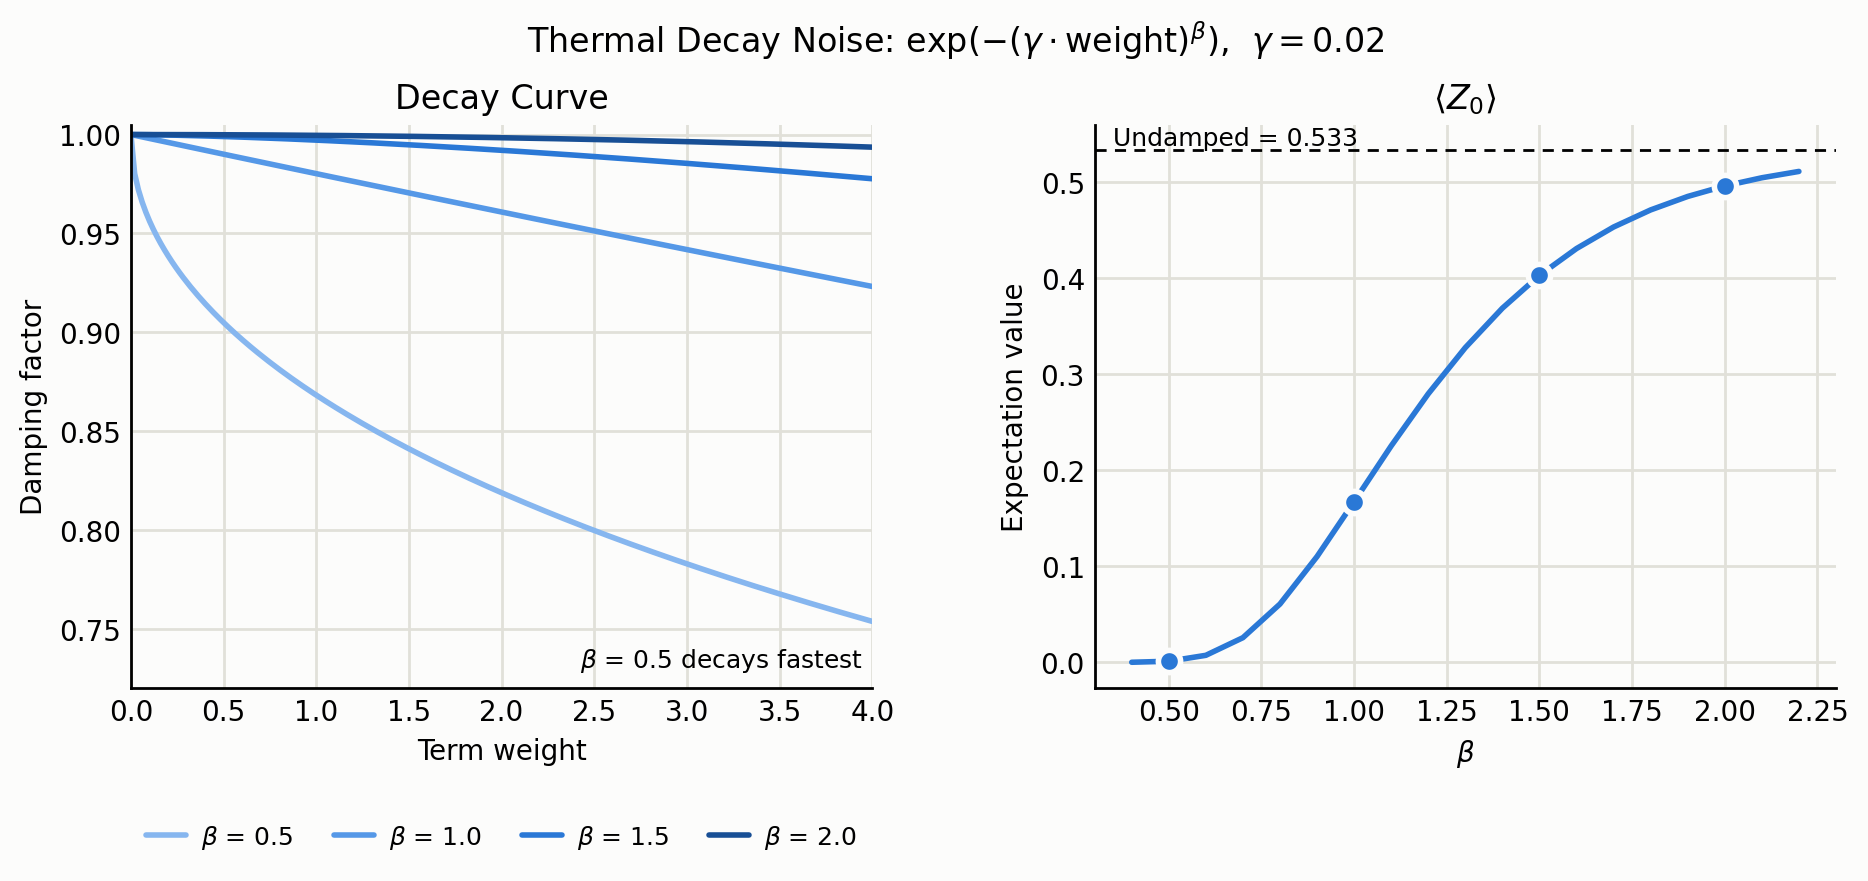

In [6]:
GAMMA = 0.02
BETAS = [0.5, 1.0, 1.5, 2.0]
UNDAMPED = run()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.4))
fig.subplots_adjust(wspace=0.30, bottom=0.24)

w = np.linspace(0, N_QUBITS, 200)
for beta, c in zip(BETAS, RAMP):
    ax1.plot(w, np.exp(-((GAMMA * w) ** beta)), color=c, linewidth=2,
             solid_capstyle="round", label=rf"$\beta$ = {beta}")
style(ax1)
ax1.set_xlim(0, N_QUBITS)
ax1.set_ylim(0.72, 1.005)
ax1.set_xlabel("Term weight")
ax1.set_ylabel("Damping factor")
ax1.set_title(r"Decay Curve", color=INK)
strip_legend(ax1, 4)

ax1.text(N_QUBITS - 0.05, 0.734, r"$\beta$ = 0.5 decays fastest",
         ha="right", va="center", color=INK_2, fontsize=9)

betas_fine = np.linspace(0.4, 2.2, 19)
vals = [run(noise=NativeNoiseModel(SO["thermal_decay_noise"],
                                   config=f'{{"gamma": {GAMMA}, "beta": {b}}}')) for b in betas_fine]
marks = [run(noise=NativeNoiseModel(SO["thermal_decay_noise"],
                                    config=f'{{"gamma": {GAMMA}, "beta": {b}}}')) for b in BETAS]
ax2.axhline(UNDAMPED, color=MUTED, linewidth=1.0, linestyle=(0, (4, 3)), zorder=1)
ax2.plot(betas_fine, vals, color=SOLO, linewidth=2, solid_capstyle="round")
ax2.plot(BETAS, marks, "o", markersize=8, color=SOLO, markeredgecolor=SURFACE,
         markeredgewidth=2, linestyle="none", zorder=3)
style(ax2)
ax2.set_xlim(0.3, 2.3)
ax2.set_xlabel(r"$\beta$")
ax2.set_ylabel("Expectation value")
ax2.set_title(r"$\langle Z_0 \rangle$", color=INK)

ax2.text(0.35, UNDAMPED, f"Undamped = {UNDAMPED:.3f}",
         ha="left", va="bottom", color=INK_2, fontsize=9)

fig.suptitle(r"Thermal Decay Noise: $\exp(-(\gamma \cdot \mathrm{weight})^{\beta})$,  $\gamma = 0.02$",
             color=INK, fontsize=12, y=1.00)
plt.show()

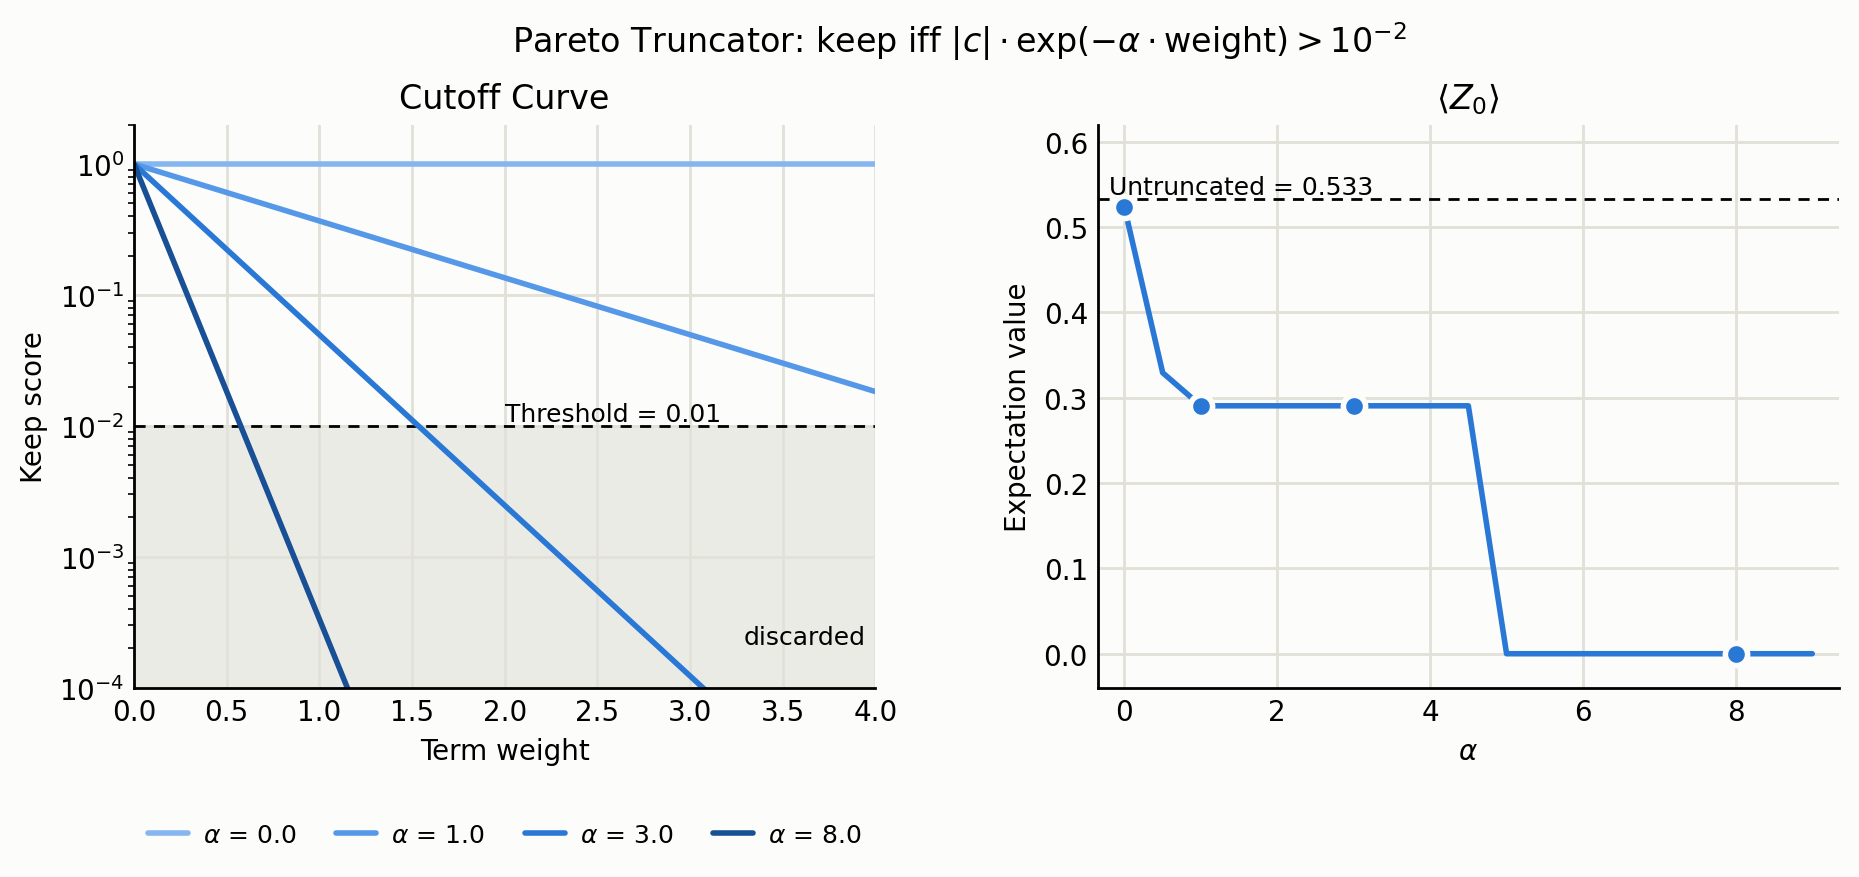

In [19]:
THRESH = 1e-2
ALPHAS = [0.0, 1.0, 3.0, 8.0]

fig, (bx1, bx2) = plt.subplots(1, 2, figsize=(11, 4.4))
fig.subplots_adjust(wspace=0.30, bottom=0.24)

wg = np.linspace(0, N_QUBITS, 200)
bx1.axhspan(1e-4, THRESH, color=GRID, alpha=0.6, zorder=0, linewidth=0)
for a, c in zip(ALPHAS, RAMP):
    bx1.plot(wg, np.exp(-a * wg), color=c, linewidth=2,
             solid_capstyle="round", label=rf"$\alpha$ = {a}")
bx1.axhline(THRESH, color=MUTED, linewidth=1.0, linestyle=(0, (4, 3)), zorder=1)
style(bx1)
bx1.set_yscale("log")
bx1.set_xlim(0, N_QUBITS)
bx1.set_ylim(1e-4, 2)
bx1.set_xlabel("Term weight")
bx1.set_ylabel("Keep score")
bx1.set_title(r"Cutoff Curve", color=INK)
strip_legend(bx1, 4)

bx1.text(2, THRESH, f"Threshold = {THRESH:g}",
         ha="left", va="bottom", color=INK_2, fontsize=9)
bx1.text(N_QUBITS - 0.05, 3e-4, "discarded",
         ha="right", va="top", color=INK_2, fontsize=9)

alphas_fine = np.linspace(0, 9, 19)
vals = [run(truncation=NativeTruncator(SO["pareto_truncator"],
                                       config=f'{{"threshold": {THRESH}, "alpha": {a}}}')) for a in alphas_fine]
marks = [run(truncation=NativeTruncator(SO["pareto_truncator"],
                                        config=f'{{"threshold": {THRESH}, "alpha": {a}}}')) for a in ALPHAS]
bx2.axhline(UNDAMPED, color=MUTED, linewidth=1.0, linestyle=(0, (4, 3)), zorder=1)
bx2.plot(alphas_fine, vals, color=SOLO, linewidth=2, solid_capstyle="round")
bx2.plot(ALPHAS, marks, "o", markersize=8, color=SOLO, markeredgecolor=SURFACE,
         markeredgewidth=2, linestyle="none", zorder=3)
style(bx2)
bx2.set_xlim(-0.35, 9.35)
bx2.set_ylim(-0.04, 0.62)
bx2.set_xlabel(r"$\alpha$")
bx2.set_ylabel("Expectation value")
bx2.set_title(r"$\langle Z_0 \rangle$", color=INK)

bx2.text(-0.2, UNDAMPED, f"Untruncated = {UNDAMPED:.3f}",
         ha="left", va="bottom", color=INK_2, fontsize=9)

fig.suptitle(r"Pareto Truncator: keep iff $|c| \cdot \exp(-\alpha \cdot \mathrm{weight}) > 10^{-2}$",
             color=INK, fontsize=12, y=1.00)
plt.show()

## Concurrency

Plugin functions can be called from every worker thread at once, sharing one
`ctx`. Making that safe is the plugin author's job.

The concurrency of a plugin is determined by its dependencies.

| `depends` | Called | Reproducible? |
|---|---|---|
| `0` (absent) | once per weight, at setup, single-threaded | yes |
| `LAYER` (2) | once per weight per layer, single-threaded | yes |
| `KEY` (1) | once per term, from every worker | user must ensure reproducibility |